# Final Project Notebook — European Option Pricing (MC vs Black–Scholes)

**Name:** Rongfeng Qiu  
**Student ID:** 488004  

**Dataset link (REQUIRED):** https://kaggle.com/datasets/mianbilal12/apple-stock-market-data-19802024?resource=download

## Goal / Research Question
**How close is Monte Carlo pricing to the Black–Scholes benchmark for European call options, and how do pricing errors change with simulation size and option parameters?**

## Notes
- This notebook reads results from **SQLite** (`data/option_pricing.db`) created by the pipeline.
- If the database does not exist yet, run in a terminal at the project root:

```bash
python -m src.pipeline --db data/option_pricing.db --recompute
```

In [1]:
# 1) Setup: find project root + connect to SQLite
import os
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start: Path | None = None) -> Path:
    """Find project root even if notebook is opened from /notebooks."""
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "data" / "option_pricing.db").exists():
            return p
        if (p / "requirements.txt").exists() and (p / "src").exists():
            return p
    return start

ROOT = find_project_root()
os.chdir(ROOT)

DB_PATH = ROOT / "data" / "option_pricing.db"
if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Database not found at: {DB_PATH}\n"
        "Run: python -m src.pipeline --db data/option_pricing.db --recompute"
    )

conn = sqlite3.connect(DB_PATH)

# (Optional) quick sanity check: list tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn
)
tables

,name
0,option_params
1,prices
2,pricing_results
3,sqlite_sequence
4,vol_summary


## 2) SQL: JOIN results table
We need a joined view of option parameters + pricing results:
- `option_params` (K, T, r, n_sim, …)
- `pricing_results` (mc_price, bs_price)

In [2]:
JOIN_SQL = """
SELECT op.symbol, op.K, op.T, op.r, op.n_sim,
       pr.mc_price, pr.bs_price,
       ABS(pr.mc_price - pr.bs_price) AS abs_error
FROM option_params op
JOIN pricing_results pr ON op.param_id = pr.param_id
ORDER BY op.n_sim, op.T, op.K;
"""

df = pd.read_sql_query(JOIN_SQL, conn)
df.head(10)

,symbol,K,T,r,n_sim,mc_price,bs_price,abs_error
0,ASSET,198.504004,0.25,0.03,50000,55.017618,54.988021,0.029597
1,ASSET,223.317004,0.25,0.03,50000,36.793140,36.770480,0.022660
2,ASSET,248.130005,0.25,0.03,50000,23.019470,22.976238,0.043232
3,ASSET,272.943005,0.25,0.03,50000,13.575670,13.495498,0.080172
4,ASSET,297.756006,0.25,0.03,50000,7.612025,7.512175,0.099850
5,ASSET,198.504004,0.50,0.03,50000,61.684865,61.633178,0.051687
6,ASSET,223.317004,0.50,0.03,50000,45.643165,45.596635,0.046529
7,ASSET,248.130005,0.50,0.03,50000,32.951981,32.865834,0.086147
8,ASSET,272.943005,0.50,0.03,50000,23.296249,23.178098,0.118151
9,ASSET,297.756006,0.50,0.03,50000,16.224007,16.057698,0.166308


## 3) SQL: AGGREGATION (mean error by maturity)

In [3]:
AGG_SQL = """
SELECT op.T AS T,
       AVG(ABS(pr.mc_price - pr.bs_price)) AS mean_abs_error,
       COUNT(*) AS n
FROM option_params op
JOIN pricing_results pr ON op.param_id = pr.param_id
GROUP BY op.T
ORDER BY op.T;
"""

agg = pd.read_sql_query(AGG_SQL, conn)
agg

,T,mean_abs_error,n
0,0.25,0.055102,5
1,0.50,0.093765,5
2,1.00,0.167645,5
3,2.00,0.338011,5


## 4) Read historical prices from SQLite (for EDA plots)

In [4]:
# Detect columns in 'prices' table robustly
info = pd.read_sql_query("PRAGMA table_info(prices);", conn)
cols = info["name"].tolist()

date_col = next((c for c in ["date", "Date", "timestamp", "Datetime"] if c in cols), None)
price_col = next((c for c in ["close", "Close", "adj_close", "Adj Close", "price", "Price"] if c in cols), None)

if date_col is None or price_col is None:
    raise ValueError(f"Could not detect date/price columns in prices table. Columns: {cols}")

prices_df = pd.read_sql_query(
    f"SELECT symbol, {date_col} AS date, {price_col} AS close FROM prices ORDER BY date;",
    conn,
)

prices_df["date"] = pd.to_datetime(prices_df["date"], errors="coerce")
prices_df = prices_df.dropna(subset=["date"]).sort_values("date")

# Simple feature engineering (logic + transformations)
prices_df["log_ret"] = np.log(prices_df["close"]).diff()
prices_df["roll_vol_21"] = prices_df["log_ret"].rolling(21).std() * np.sqrt(252)

prices_df.head()

C:\Users\Ryan\AppData\Local\Temp\ipykernel_8204\852297874.py:16: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  prices_df["date"] = pd.to_datetime(prices_df["date"], errors="coerce")


,symbol,date,close,log_ret,roll_vol_21
0,ASSET,1980-12-12 00:00:00-05:00,0.098834,NaN,NaN
1,ASSET,1980-12-15 00:00:00-05:00,0.093678,-0.053581,NaN
2,ASSET,1980-12-16 00:00:00-05:00,0.086802,-0.076231,NaN
3,ASSET,1980-12-17 00:00:00-05:00,0.088951,0.024450,NaN
4,ASSET,1980-12-18 00:00:00-05:00,0.091530,0.028580,NaN


# Visualizations (5–10 plots)
Below are **multiple plot types**: line, scatter, bar, histogram, boxplot, and Q–Q plot.

> Tip: run cells top→down using **Shift + Enter**.

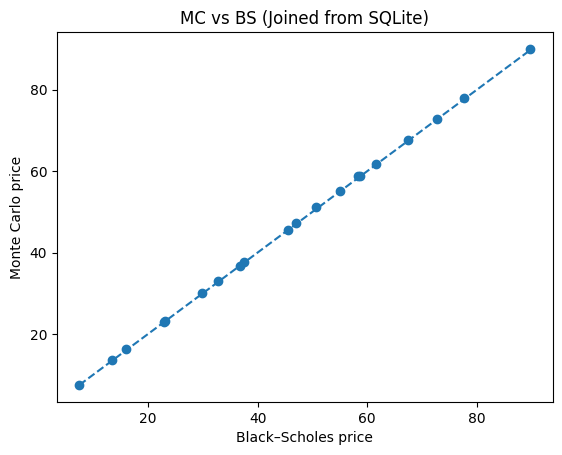

In [5]:
# Plot 1 — MC vs BS (scatter)
plt.figure()
plt.scatter(df["bs_price"], df["mc_price"])
xmin, xmax = df["bs_price"].min(), df["bs_price"].max()
plt.plot([xmin, xmax], [xmin, xmax], linestyle="--")
plt.xlabel("Black–Scholes price")
plt.ylabel("Monte Carlo price")
plt.title("MC vs BS (Joined from SQLite)")
plt.show()

**Interpretation:** Points close to the dashed 45° line indicate that Monte Carlo estimates closely match the Black–Scholes benchmark. Deviations reflect simulation noise.

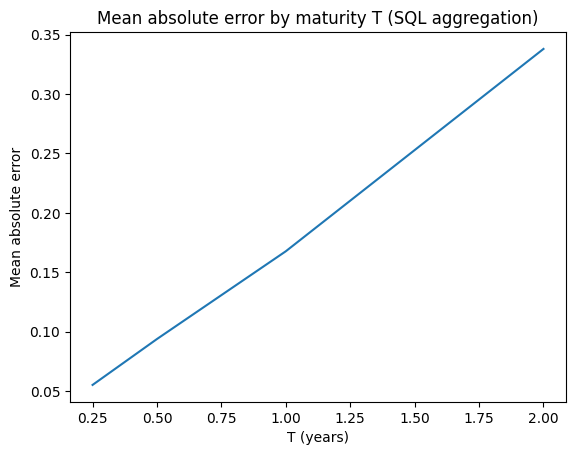

In [6]:
# Plot 2 — Mean absolute error by maturity T (SQL aggregation)
plt.figure()
plt.plot(agg["T"], agg["mean_abs_error"])
plt.xlabel("T (years)")
plt.ylabel("Mean absolute error")
plt.title("Mean absolute error by maturity T (SQL aggregation)")
plt.show()

**Interpretation:** Longer maturities often show larger pricing uncertainty because payoffs depend on a longer simulated horizon.

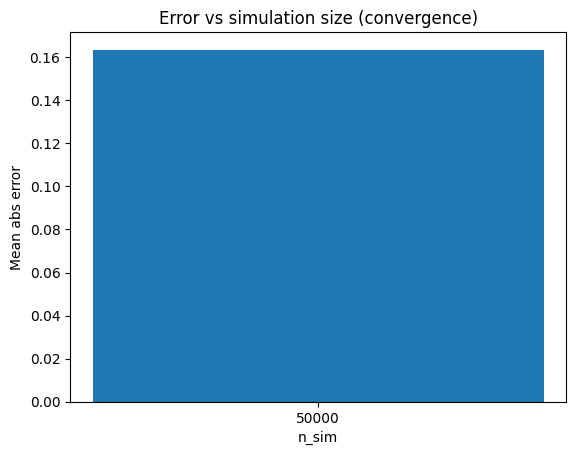

In [7]:
# Plot 3 — Mean absolute error by number of simulations (n_sim)
err_by_n = df.groupby("n_sim", as_index=False)["abs_error"].mean()
plt.figure()
plt.bar(err_by_n["n_sim"].astype(str), err_by_n["abs_error"])
plt.xlabel("n_sim")
plt.ylabel("Mean abs error")
plt.title("Error vs simulation size (convergence)")
plt.show()

**Interpretation:** Increasing simulation size should reduce Monte Carlo noise, so average absolute error typically decreases when n_sim increases.

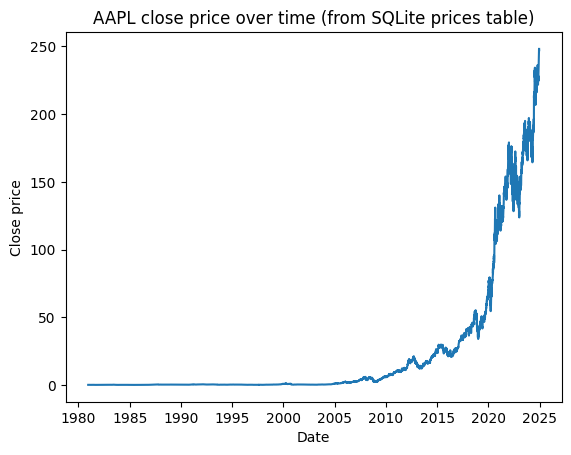

In [8]:
# Plot 4 — Close price over time (line)
plt.figure()
plt.plot(prices_df["date"], prices_df["close"])
plt.xlabel("Date")
plt.ylabel("Close price")
plt.title("AAPL close price over time (from SQLite prices table)")
plt.show()

**Interpretation:** This shows the historical trend in the underlying asset price used to estimate volatility for option pricing.

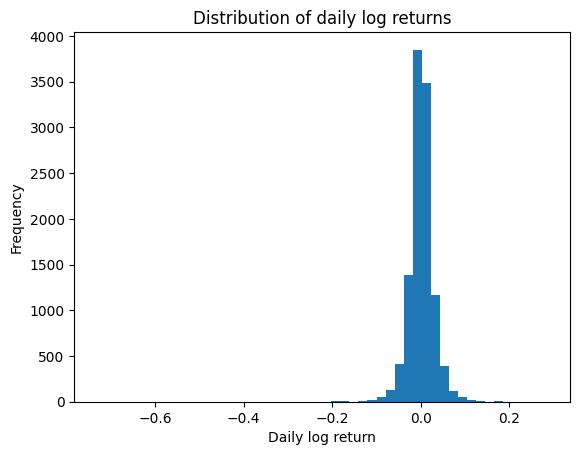

In [9]:
# Plot 5 — Distribution of log returns (histogram)
rets = prices_df["log_ret"].dropna()
plt.figure()
plt.hist(rets, bins=50)
plt.xlabel("Daily log return")
plt.ylabel("Frequency")
plt.title("Distribution of daily log returns")
plt.show()

**Interpretation:** The return distribution is centered near zero and shows dispersion that relates to volatility (risk) of the asset.

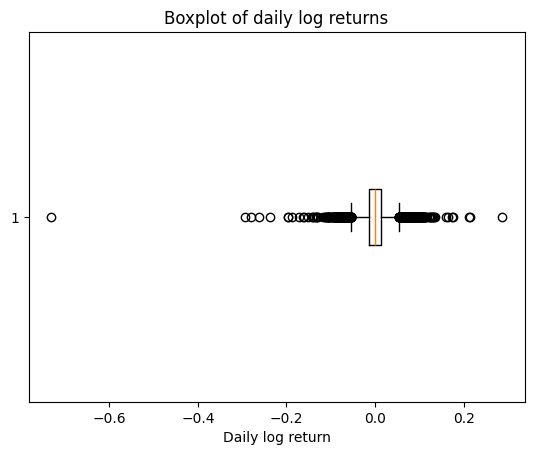

In [10]:
# Plot 6 — Returns boxplot (boxplot)
plt.figure()
plt.boxplot(rets, vert=False)
plt.xlabel("Daily log return")
plt.title("Boxplot of daily log returns")
plt.show()

**Interpretation:** The boxplot highlights outliers (extreme returns), which can strongly affect volatility estimates.

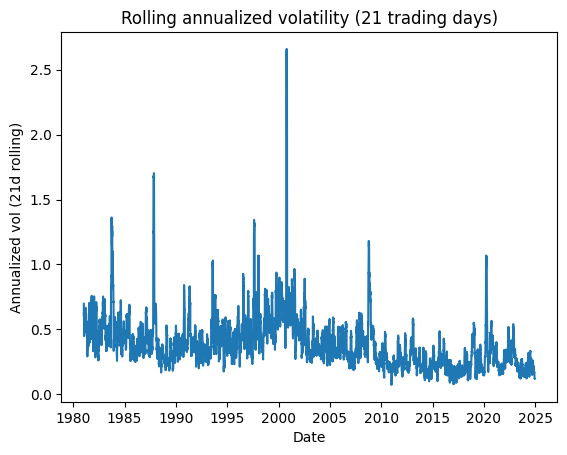

In [11]:
# Plot 7 — Rolling annualized volatility (line)
plt.figure()
plt.plot(prices_df["date"], prices_df["roll_vol_21"])
plt.xlabel("Date")
plt.ylabel("Annualized vol (21d rolling)")
plt.title("Rolling annualized volatility (21 trading days)")
plt.show()

**Interpretation:** Volatility is time-varying. Using rolling volatility illustrates changing market risk over time.

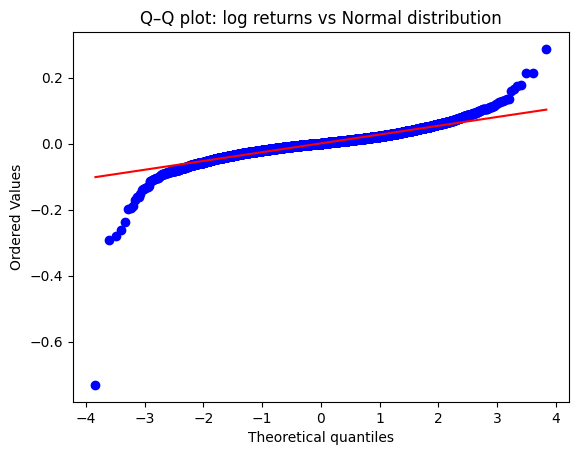

In [12]:
# Plot 8 — Q-Q plot of returns vs Normal (diagnostic plot)
from scipy import stats

plt.figure()
stats.probplot(rets, dist="norm", plot=plt)
plt.title("Q–Q plot: log returns vs Normal distribution")
plt.show()

**Interpretation:** If points deviate from the straight line, returns are not perfectly normal (e.g., fat tails), which is important for risk and pricing assumptions.

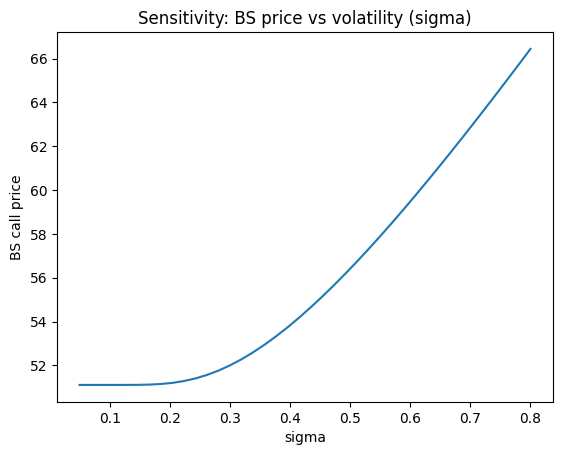

In [13]:
# Plot 9 — Black–Scholes sensitivity to volatility (sigma)
import math

def bs_call_price(S: float, K: float, T: float, r: float, sigma: float) -> float:
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    N = lambda x: 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))
    return S * N(d1) - K * math.exp(-r * T) * N(d2)

# choose one row as example (control flow: fallback if df empty)
if len(df) == 0:
    raise ValueError("No pricing rows found in DB to run sensitivity plot.")

row = df.iloc[0]
S0 = float(prices_df["close"].iloc[-1])
K0 = float(row["K"])
T0 = float(row["T"])
r0 = float(row["r"])

sigmas = np.linspace(0.05, 0.80, 40)
bs_prices = [bs_call_price(S0, K0, T0, r0, float(s)) for s in sigmas]

plt.figure()
plt.plot(sigmas, bs_prices)
plt.xlabel("sigma")
plt.ylabel("BS call price")
plt.title("Sensitivity: BS price vs volatility (sigma)")
plt.show()

**Interpretation:** Option value increases with volatility because higher uncertainty raises the expected payoff of a call option.

In [14]:
# Close DB connection (good practice)
conn.close()
print("Done.")

Done.
